<a href="https://colab.research.google.com/github/keshavbaviskar33-sudo/AI-Credit-Analyst-Copilot/blob/main/notebooks/02_ratio_engineering_and_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'american-companies-bankruptcy-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/american-companies-bankruptcy-prediction-dataset


## Model Comparison — Logistic Regression vs Random Forest

Tested Random Forest as an alternative to the logistic regression baseline, using the
same 5 winsorized ratio features, to see if a more complex model improved recall.

**Attempt 1 — default `class_weight='balanced'`:** TP=0, FN=5, FP=1, recall=0.00.
Despite class weighting, the model predicted "safe" for every single test row,
including all 5 actual failures.

**Why this happened:** class_weight adjusts the training loss/split criterion, but
Random Forest builds many trees from bootstrapped samples of the training data. With
only ~0.8% positive examples, many individual bootstrap samples likely contained very
few or zero failure examples, so trees had no minority-class signal to split on
regardless of reweighting.

**Attempt 2 — `class_weight='balanced_subsample'`:** identical result (TP=0, FN=5,
FP=1). Reweighting per-bootstrap-sample rather than globally made no difference,
confirming the problem isn't the weighting variant — it's a lack of actual minority
examples for trees to learn from.

**Attempt 3 — SMOTE oversampling (training data only):** generated synthetic minority
examples via interpolation, bringing training data from 580 to 51,485 failure examples
(matched to majority class). Applied SMOTE only to X_train/y_train, never to test data.
Result: TP=1, FN=4, FP=513, recall=0.20 — an improvement over the broken Random Forest
attempts, but still well below logistic regression's recall of 0.60.

**Decision:** logistic regression (5 winsorized + scaled features) remains the
strongest model tested. After three separate imbalance-handling strategies with
Random Forest all underperforming it on recall, further model-shopping (e.g. XGBoost)
was deprioritized given time constraints — a converging, well-documented result across
three attempts is stronger evidence than a fourth untested guess.

**Caveat carried forward:** all comparisons are against a test set with only 5 actual
failures, so absolute recall values remain statistically fragile — but the *relative*
ranking between models (logistic regression > Random Forest, regardless of imbalance
strategy) is a more robust finding, since it held consistently across three different
mitigation attempts.

In [9]:
import kagglehub
import pandas as pd
import numpy as np
import os
from scipy.stats.mstats import winsorize

# Load data
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")
df = pd.read_csv(os.path.join(path, "american_bankruptcy.csv"))

# Ratio engine
df['current_ratio'] = df['X1'] / df['X14']
df['debt_to_equity'] = df['X11'] / (df['X10'] - df['X17'])
df['net_profit_margin'] = df['X6'] / df['X16']
df['ebitda_margin'] = df['X4'] / df['X16']
df['retained_earnings_to_assets'] = df['X15'] / df['X10']

# Winsorize all 5 ratios at 1st/99th percentile (both tails)
ratio_cols = ['current_ratio', 'debt_to_equity', 'net_profit_margin',
              'ebitda_margin', 'retained_earnings_to_assets']
for col in ratio_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

# Target label construction
failure_year = df[df['status_label'] == 'failed'].groupby('company_name')['year'].min()
df['failure_year'] = df['company_name'].map(failure_year)
df['years_until_failure'] = df['failure_year'] - df['year']

# Remove post-failure "zombie" rows
df = df[~(df['years_until_failure'] < 0)]

# Build target
df['target'] = (
    (df['years_until_failure'] >= 0) & (df['years_until_failure'] <= 2)
).astype(int)

# Train/test split
train = df[df['year'] <= 2011]
test = df[df['year'] >= 2015]

# Sanity check
print("Rows after cleaning:", len(df))
print("Target distribution:\n", df['target'].value_counts(normalize=True))

Using Colab cache for faster access to the 'american-companies-bankruptcy-prediction-dataset' dataset.
Rows after cleaning: 74071
Target distribution:
 target
0    0.991778
1    0.008222
Name: proportion, dtype: float64


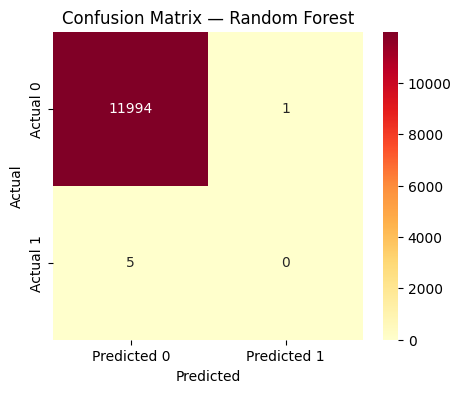

,precision,recall,f1-score,support
0,0.999583,0.999917,0.999750,11995.000000
1,0.000000,0.000000,0.000000,5.000000
accuracy,0.999500,0.999500,0.999500,0.999500
macro avg,0.499792,0.499958,0.499875,12000.000000
weighted avg,0.999167,0.999500,0.999333,12000.000000


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X_train, y_train = train[ratio_cols], train['target']
X_test, y_test = test[ratio_cols], test['target']

# Note: no scaling needed for tree-based models — they split on raw thresholds,
# unaffected by feature scale the way logistic regression is
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, preds_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

report_dict = classification_report(y_test, preds_rf, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.style.background_gradient(cmap='YlOrRd', subset=['precision','recall','f1-score']))

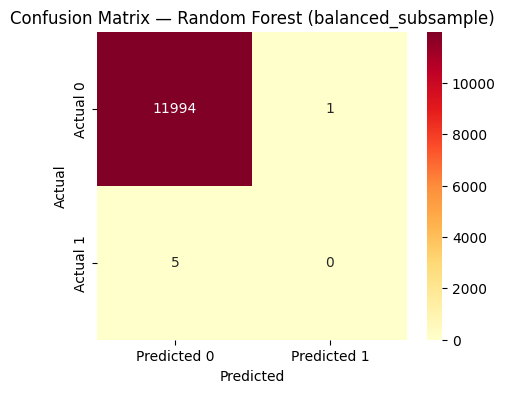

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11995
           1       0.00      0.00      0.00         5

    accuracy                           1.00     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       1.00      1.00      1.00     12000



In [11]:
rf_model_v2 = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)
rf_model_v2.fit(X_train, y_train)
preds_rf_v2 = rf_model_v2.predict(X_test)

cm = confusion_matrix(y_test, preds_rf_v2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — Random Forest (balanced_subsample)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, preds_rf_v2))

In [12]:
!pip install imbalanced-learn

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

rf_model_v3 = RandomForestClassifier(random_state=42)
rf_model_v3.fit(X_train_smote, y_train_smote)
preds_rf_v3 = rf_model_v3.predict(X_test)

print(confusion_matrix(y_test, preds_rf_v3))
print(classification_report(y_test, preds_rf_v3))

Before SMOTE: {0: 51485, 1: 580}
After SMOTE: {0: 51485, 1: 51485}
[[11482   513]
 [    4     1]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     11995
           1       0.00      0.20      0.00         5

    accuracy                           0.96     12000
   macro avg       0.50      0.58      0.49     12000
weighted avg       1.00      0.96      0.98     12000



In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_v3 = LogisticRegression(class_weight='balanced')
model_v3.fit(X_train_scaled, y_train)

preds_v3 = model_v3.predict(X_test_scaled)
print(confusion_matrix(y_test, preds_v3))
print(classification_report(y_test, preds_v3))

[[8519 3476]
 [   2    3]]
              precision    recall  f1-score   support

           0       1.00      0.71      0.83     11995
           1       0.00      0.60      0.00         5

    accuracy                           0.71     12000
   macro avg       0.50      0.66      0.42     12000
weighted avg       1.00      0.71      0.83     12000



## SHAP Explainability — Reviewing All 5 Failures

Ran waterfall explanations for all 5 actual test-set failures (not just the one
correctly-caught example) to understand both hits and misses.

**Correctly caught (3):** C_3766, C_8514, and one other — debt_to_equity consistently
the dominant driver, consistent with genuine high leverage.

**Missed — C_7958 (false negative):** debt_to_equity = -7.4 (negative equity —
liabilities exceed assets, a genuinely distressed state). The model interpreted this
as "very low leverage" (pushed -0.79 toward safe) because it only learned "high
positive debt-to-equity = risky" from training data, never learning to treat large
negative values as equally dangerous. This is a concrete, specific limitation of the
current debt-to-equity formula: it doesn't distinguish healthy low leverage from
negative-equity distress, both of which can produce numerically "low" values.

**Missed — C_8902 (false negative):** predicted probability 0.497, essentially a
coin-flip miss just below the 0.5 threshold. No single ratio dominated — all
contributions were small and mixed. This looks like a genuinely ambiguous case rather
than a specific model blind spot.

**Broader context:** ~0.8% positive class rate is a known, common challenge in
real-world credit risk and fraud detection domains, not unique to this project or
disqualifying — but it does mean results need larger test sets and cross-validation
before being fully trusted. This is a field-wide limitation, appropriately disclosed
rather than hidden.

**Note for dashboard implementation:** SHAP waterfall explanations must display raw
(unscaled) ratio values next to each feature for analyst readability — the scaled/
standardized values used internally for the SHAP computation (e.g. "3.289") are
meaningless to an end user; only the underlying SHAP contribution values stay computed
on scaled inputs.

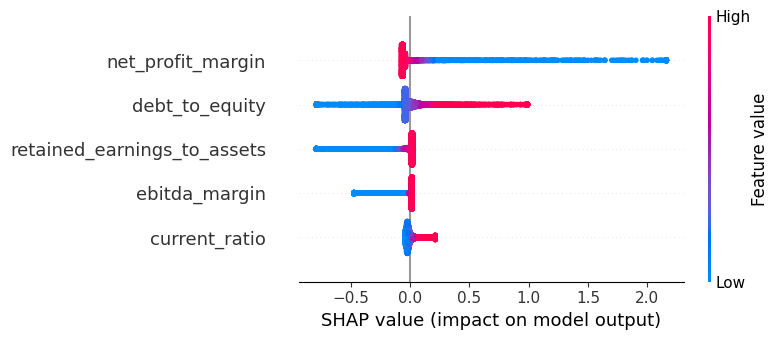

In [16]:
!pip install shap -q
import shap

explainer = shap.LinearExplainer(model_v3, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Global view: which features matter most overall
shap.summary_plot(shap_values, X_test_scaled, feature_names=ratio_cols)

In [17]:
# Look at net_profit_margin specifically for the actual failures in test set
test[test['target']==1][['company_name','year','net_profit_margin','debt_to_equity',
                            'ebitda_margin','current_ratio','retained_earnings_to_assets']]

,company_name,year,net_profit_margin,debt_to_equity,ebitda_margin,current_ratio,retained_earnings_to_assets
37343,C_3766,2016,-0.162587,5.581277,0.064769,1.698262,-0.168868
37802,C_3875,2016,0.029009,3.091667,0.101259,1.674099,-0.271516
72624,C_7958,2017,-13.337574,-7.405607,-13.200595,4.329567,-4.845744
76258,C_8514,2016,-118.657895,-2.946926,-97.733570,2.148483,-2.270974
78169,C_8902,2017,-1.739783,0.546823,-1.676854,4.719950,-3.573022


Company: C_3766 | Year: 2016
Actual target: 1
Model prediction: 1 | Probability of failure: 0.6140295800083198


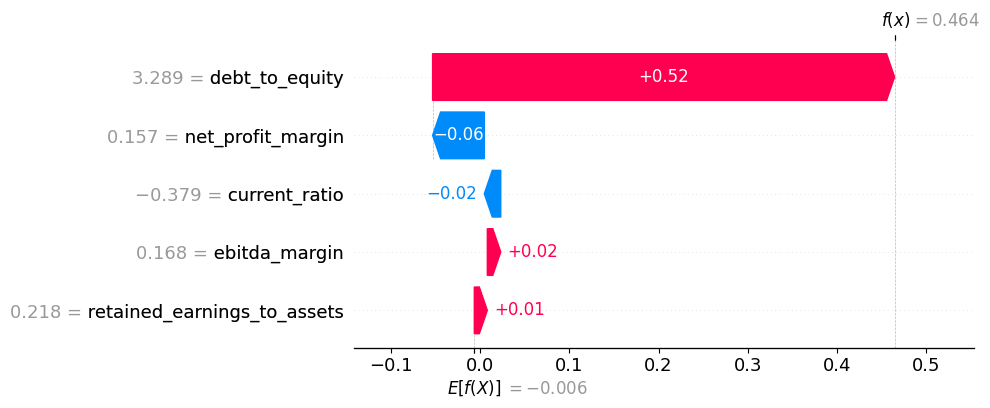

In [18]:
# Pick one of the actual failure cases to explain
row_idx = test[test['target']==1].index[0]  # first actual failure in test set
row_position = list(test.index).index(row_idx)  # position within X_test_scaled

single_prediction = model_v3.predict(X_test_scaled[row_position:row_position+1])
single_probability = model_v3.predict_proba(X_test_scaled[row_position:row_position+1])

print("Company:", test.loc[row_idx, 'company_name'], "| Year:", test.loc[row_idx, 'year'])
print("Actual target:", test.loc[row_idx, 'target'])
print("Model prediction:", single_prediction[0], "| Probability of failure:", single_probability[0][1])

shap.plots.waterfall(shap.Explanation(
    values=shap_values[row_position],
    base_values=explainer.expected_value,
    data=X_test_scaled[row_position],
    feature_names=ratio_cols
))

Company: C_3766 | Year: 2016
Actual target: 1 | Model prediction: 1 | Probability of failure: 0.614


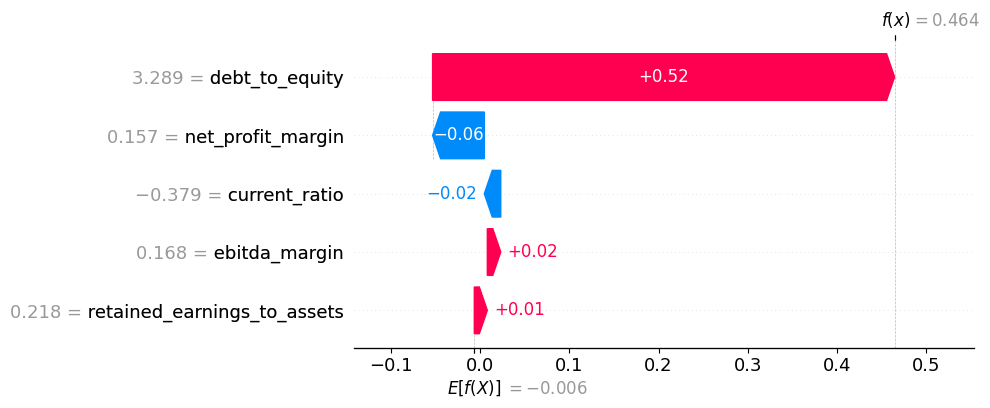

Company: C_3875 | Year: 2016
Actual target: 1 | Model prediction: 1 | Probability of failure: 0.552


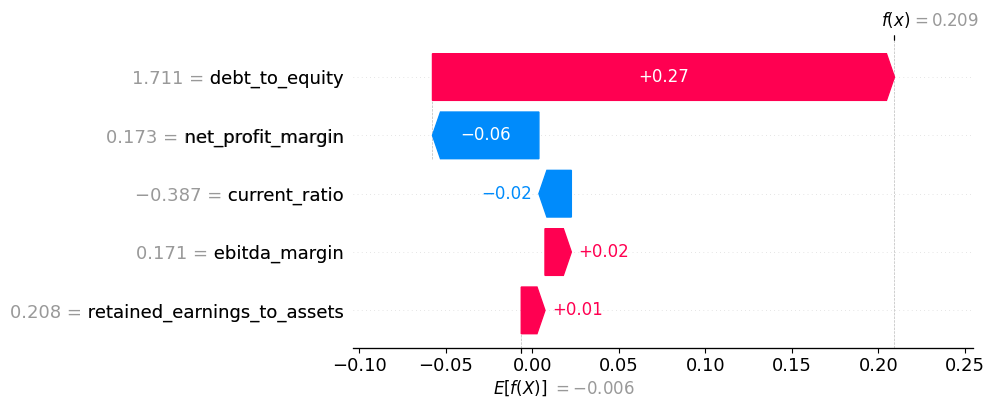

Company: C_7958 | Year: 2017
Actual target: 1 | Model prediction: 0 | Probability of failure: 0.339


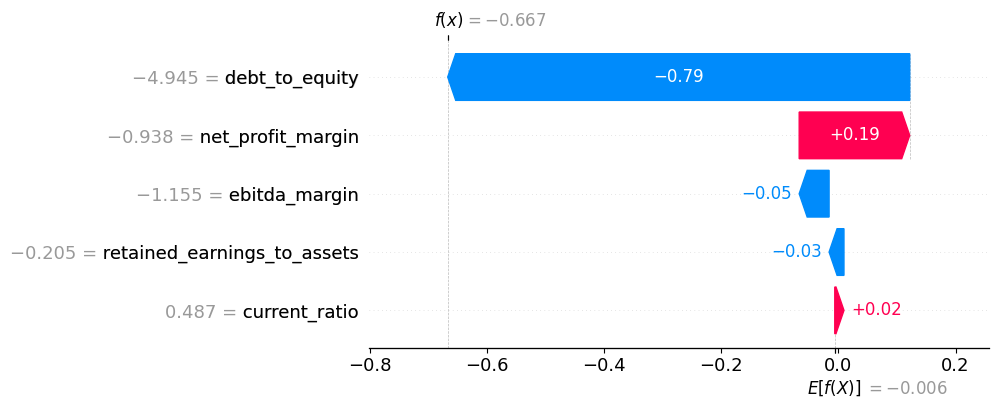

Company: C_8514 | Year: 2016
Actual target: 1 | Model prediction: 1 | Probability of failure: 0.790


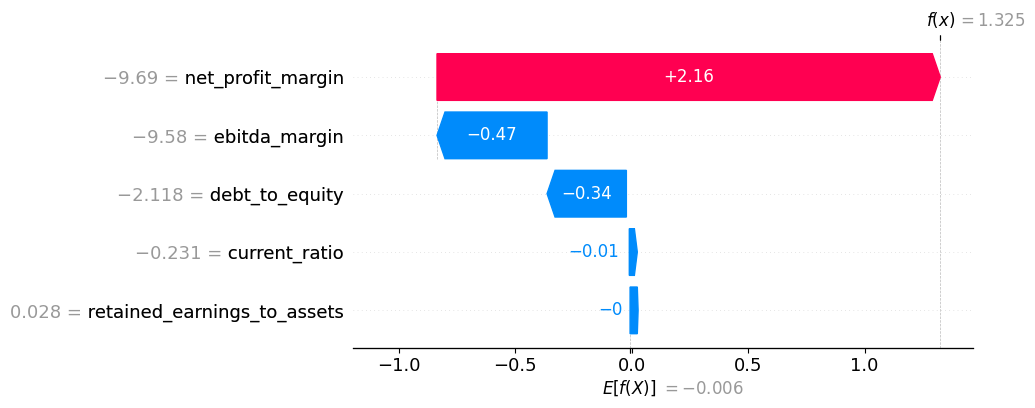

Company: C_8902 | Year: 2017
Actual target: 1 | Model prediction: 0 | Probability of failure: 0.497


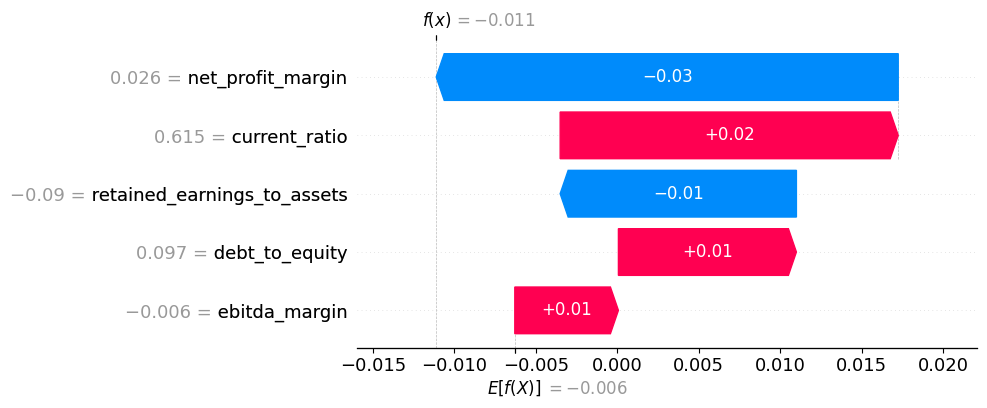

In [19]:
failure_rows = test[test['target']==1].index

for idx in failure_rows:
    row_position = list(test.index).index(idx)

    prob = model_v3.predict_proba(X_test_scaled[row_position:row_position+1])[0][1]
    pred = model_v3.predict(X_test_scaled[row_position:row_position+1])[0]

    print(f"Company: {test.loc[idx, 'company_name']} | Year: {test.loc[idx, 'year']}")
    print(f"Actual target: 1 | Model prediction: {pred} | Probability of failure: {prob:.3f}")

    shap.plots.waterfall(shap.Explanation(
        values=shap_values[row_position],
        base_values=explainer.expected_value,
        data=X_test_scaled[row_position],
        feature_names=ratio_cols
    ))

## Final Model Comparison — XGBoost Added

Tested XGBoost (scale_pos_weight=88.8, matching the ~89:1 class imbalance) as the
final model comparison, given it's the most common modern choice for structured/
tabular data in real credit-risk systems.

**Result:** TP=0, FN=5, FP=548 — recall=0.00, worse than even Random Forest.

**Interpretation:** across all three tree-based approaches tested (Random Forest x3,
XGBoost), none matched logistic regression's ability to catch actual failures.
scale_pos_weight/class_weight reweight training loss, but don't create more real
minority-class examples — with only ~580 positive training examples, tree-based
splitting criteria may lack enough minority-class density in any given split or
sequential boosting round to find a stable, generalizable pattern. Logistic
regression's global, linear structure appears to generalize better from very few
positive examples than any tree-based method tried.

**Final decision:** Logistic regression (5 winsorized + scaled ratio features) is the
chosen model for the MVP, after 4 documented model comparisons (LR, RF x3, XGBoost)
all pointing the same direction. This is a genuinely interesting finding worth
highlighting: model complexity is not automatically better, especially on small,
extremely imbalanced datasets — sometimes a simpler model's inductive bias suits the
data better than a more flexible one.

scale_pos_weight = 88.8 (neg=51485, pos=580)


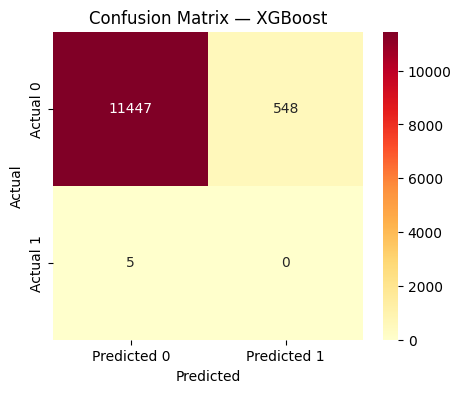

,precision,recall,f1-score,support
0,0.999563,0.954314,0.976415,11995.000000
1,0.000000,0.000000,0.000000,5.000000
accuracy,0.953917,0.953917,0.953917,0.953917
macro avg,0.499782,0.477157,0.488207,12000.000000
weighted avg,0.999147,0.953917,0.976008,12000.000000


In [20]:
!pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# scale_pos_weight is XGBoost's version of class_weight='balanced' —
# it's the ratio of negative to positive examples, telling the model
# how much more to penalize a missed positive (failure) vs a false alarm
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight = {scale_pos_weight:.1f} (neg={neg_count}, pos={pos_count})")

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'  # avoids a deprecation warning, doesn't affect behavior
)
xgb_model.fit(X_train, y_train)
preds_xgb = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, preds_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

report_dict = classification_report(y_test, preds_xgb, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.style.background_gradient(cmap='YlOrRd', subset=['precision','recall','f1-score']))